In [17]:
import pandas as pd
import lightkurve as lk 
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable
from astropy import units as u

%run pipeline.ipynb

import warnings
warnings.filterwarnings("ignore")

pd.set_option('display.max_columns', None)

In [18]:
dtypes={'pop_id':'Int64','TIC':'string','gaiadr3_source_id':'string','epic_id':'string'}
lctable=pd.read_csv('lcscoresreformat.csv',dtype=dtypes)

In [19]:
lctable[lctable.pop_id==30]

,pop_id,lcname,idtype,ID,secorcamp,LC_author,cadence,fluxamplitude,TIC,gaiadr3_source_id,epic_id,per,group,age_Myr,disco_paper,paper_author,year,Score,Flare,Shelf,Evolution,Notes,per_col
91,30,TIC-309321971-11-FFI-30min,TIC,309321971,11,FFI,30min,0.018791,309321971,5901773217829654912,<NA>,0.6314,UCL/LCC,16.0,Rebull_2022,Rebull,2022,2,2,1,1,NaN,one
92,30,TIC-309321971-38-FFI-10min,TIC,309321971,38,FFI,10min,0.020249,309321971,5901773217829654912,<NA>,0.6314,UCL/LCC,16.0,Rebull_2022,Rebull,2022,2,2,1,1,Flare affecting shelf,one
93,30,TIC-309321971-65-FFI-200s,TIC,309321971,65,FFI,200s,0.017098,309321971,5901773217829654912,<NA>,0.6314,UCL/LCC,16.0,Rebull_2022,Rebull,2022,2,1,1,1,Literature period a little off,one


In [63]:
lc64=get_lc_string('TIC-309321971-38-FFI-10min')

In [64]:
lc64.time[0]

<Time object: scale='tdb' format='jd' value=2333.8622306341467>

In [65]:
per64=u.Quantity(lctable[lctable.pop_id==30].per.iloc[0],u.d)
per64

<Quantity 0.6314 d>

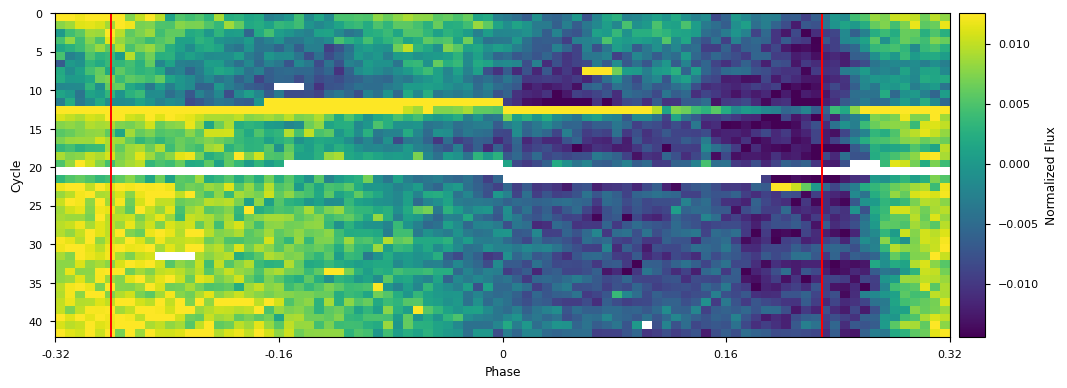

In [66]:
subgraph_rp(lc64,period=per64)

In [67]:
lc64.flux = lc64.flux + 1

In [68]:
lc64.time=lc64.time - lc64.time[0].value

In [69]:
lc64.time = lc64.time.jd / per64.value

In [70]:
lc64.time=lc64.time - 0.5

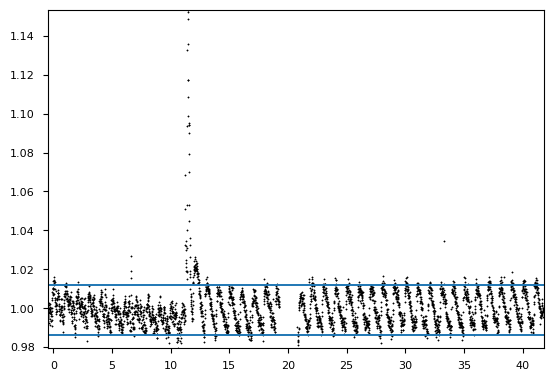

In [71]:
plt.close()
plt.scatter(lc64["time"].value, lc64["flux"], 1, "#000000", alpha=1)
plt.margins(0)
plt.axhline(y=1.012)
plt.axhline(y=0.986)
plt.show()

In [72]:
leftdate=10
rightdate=15

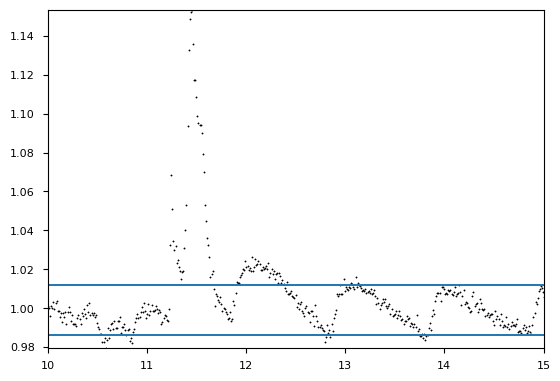

In [73]:
plt.close()
plt.scatter(lc64["time"].value, lc64["flux"], 1, "#000000", alpha=1)
plt.margins(0)
plt.xlim([leftdate,rightdate])
plt.axhline(y=1.012)
plt.axhline(y=0.986)
plt.show()

In [27]:
#lc64h1=lc64[lc64.time.value<leftdate]

In [28]:
# plt.close()
# plt.scatter(lc64h1["time"].value, lc64h1["flux"], 1, "#000000", alpha=1)
# plt.margins(0)
# plt.show()

In [29]:
#lc64h2=lc64[lc64.time.value>rightdate]

In [30]:
# plt.close()
# plt.scatter(lc64h2["time"].value, lc64h2["flux"], 1, "#000000", alpha=1)
# plt.margins(0)
# plt.show()

In [31]:
#bin64=u.Quantity(per64/200,u.s)

In [32]:
#epoch64=lc64.time[0]

In [33]:
#subgraph_phaselc(lc64h1,period=per64,bintime=bin64,epoch_time=epoch64)

In [34]:
#subgraph_phaselc(lc64h2,period=per64,bintime=bin64,epoch_time=epoch64)

In [35]:
#lctable[np.logical_and(lctable.pop_id==28, lctable.secorcamp==11)].lcname.values[0]

In [36]:
def double_lc(pop_id,sector,removedays,period=1):
    lcrow=lctable[np.logical_and(lctable.pop_id==pop_id, lctable.secorcamp==sector)]
    lcname=lcrow.lcname.values[0]
    lc=get_lc_string(lcname)
    if lcrow.LC_author.values[0]=='FFI':
        lc.flux=lc.flux+1
    else:
        lc=lc.normalize()
    if period==1:
        period=u.Quantity(lcrow.per.values[0],u.d)
    else:
        period=u.Quantity(lcrow.per2.values[0],u.d)
    bintime=u.Quantity(period/200,u.s)
    epoch=lc.time[0]

    minday=removedays[0]
    maxday=removedays[1]
    lc1=lc[lc.time.value<minday]
    lc2=lc[lc.time.value>maxday]
    
    fig, (ax1, ax2) = plt.subplots(1, 2, sharey=True, figsize=(10, 4))
    subgraph_phaselc(lc1,period=period,ax=ax1,bintime=bintime,showperiod=False,epoch_time=epoch)
    subgraph_phaselc(lc2,period=period,ax=ax2,bintime=bintime,showperiod=False,epoch_time=epoch)
    ax1.set_ylabel('')
    ax2.set_ylabel('')
    ax1.set_xlabel('')
    ax2.set_xlabel('')
    ax1.set_xticklabels([])
    ax2.set_xticklabels([])
    ax1.set_xticks([])
    ax2.set_xticks([])
    ax1.tick_params(direction='in')
    ax2.tick_params(direction='in')
    plt.subplots_adjust(wspace=0)
    fig.suptitle(f'TIC {lcrow.TIC.values[0]}, Sector {sector}, {period}',y=0.94)
    fig.savefig(f'multiplots/sectorsplit/{pop_id}_{sector}.png',bbox_inches='tight')
    return fig

In [37]:
#double_lc(28,64,(leftdate,rightdate))

In [38]:
def double_lc_withriver(pop_id, sector, removedays, period=1):

    lcrow = lctable[np.logical_and(lctable.pop_id == pop_id,
                                   lctable.secorcamp == sector)]
    lcname = lcrow.lcname.values[0]
    lc = get_lc_string(lcname)

    if lcrow.LC_author.values[0] == 'FFI':
        lc.flux = lc.flux + 1
    else:
        lc = lc.normalize()

    if period == 1:
        period = u.Quantity(lcrow.per.values[0], u.d)
    else:
        period = u.Quantity(lcrow.per2.values[0], u.d)

    bintime = u.Quantity(period / 200, u.s)
    epoch = lc.time[0]

    minday, maxday = removedays
    lc1 = lc[lc.time.value < minday]
    lc2 = lc[lc.time.value > maxday]

    # ---- Figure + layout ----
    fig, (ax1, ax2, ax3) = plt.subplots(
        1, 3,
        figsize=(12, 4),
        sharey=False,
        gridspec_kw={"wspace": 0.1}   # even spacing between all panels
    )

    # Share y only between ax1 and ax2
    ax2.sharey(ax1)

    # ---- Plotting ----
    subgraph_phaselc(lc1, period=period, ax=ax1,
                     bintime=bintime, showperiod=False,
                     epoch_time=epoch)

    subgraph_phaselc(lc2, period=period, ax=ax2,
                     bintime=bintime, showperiod=False,
                     epoch_time=epoch)

    cbar=subgraph_rp(lc, period=period, epoch_time=epoch,
                redlines=False, ax=ax3,returncbar=True,dates=removedays)

    # ---- Axis formatting ----

    for ax in [ax1, ax2, ax3]:
        ax.tick_params(axis='y', pad=2)
        ax.set_xlabel('')
        ax.set_ylabel('')

    cbar.ax.tick_params(pad=2)
    cbar.set_label('')

    # Consistent x ticks for phase panels
    p2 = round(period.value / 2, 2)
    p4 = round(period.value / 4, 2)
    time_ticks = [-p2, -p4, 0, p4, p2]

    for ax in [ax1, ax2]:
        ax.set_xlim(-p2, p2)
        ax.set_xticks(time_ticks)

    # Hide duplicate y tick labels on ax2
    plt.setp(ax2.get_yticklabels(), visible=False)

    # ---- Title + save ----
    fig.suptitle(
        f'TIC {lcrow.TIC.values[0]}, Sector {sector}, {period}',
        y=0.94
    )

    fig.savefig(
        f'multiplots/sectorsplit/{pop_id}_{sector}_withriver.png',
        bbox_inches='tight'
    )

    return fig

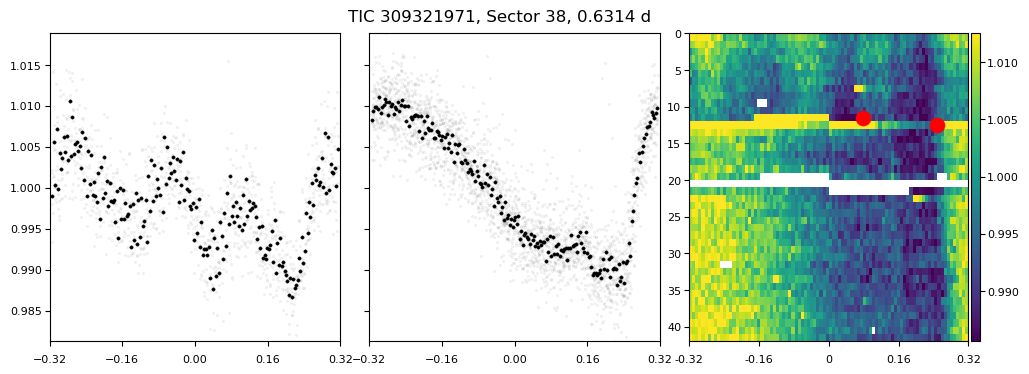

In [40]:
double_lc_withriver(30,38,(leftdate,rightdate))

In [41]:
pop_id=30
sector=38
removedays=(leftdate,rightdate)
period=1

lcrow = lctable[np.logical_and(lctable.pop_id == pop_id,
                                   lctable.secorcamp == sector)]
lcname = lcrow.lcname.values[0]
lc = get_lc_string(lcname)

if lcrow.LC_author.values[0] == 'FFI':
    lc.flux = lc.flux + 1
else:
    lc = lc.normalize()

if period == 1:
    period = u.Quantity(lcrow.per.values[0], u.d)
else:
    period = u.Quantity(lcrow.per2.values[0], u.d)

bintime = u.Quantity(period / 200, u.s)
epoch = lc.time[0]

In [42]:
print(epoch)

2333.8622306341467


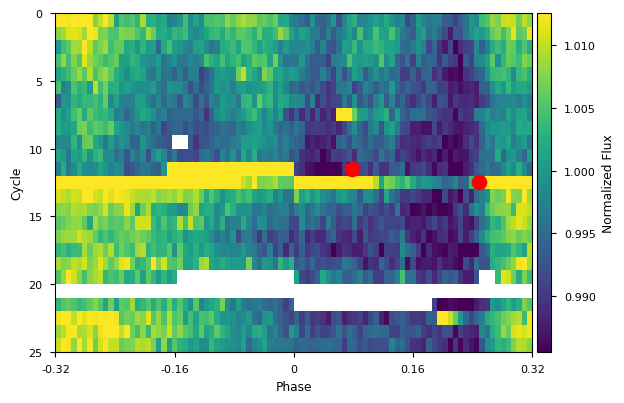

In [46]:
plt.close('all')
fig,ax=plt.subplots()
subgraph_rp(lc, period=period, epoch_time=epoch,
                redlines=False, ax=ax,returncbar=True,dates=removedays)
ax.set_ylim(25,0)
plt.show()